In [1]:
!pip install yfinance tensorflow pandas numpy matplotlib scikit-learn

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

data = data[['Close']]
data.head()

/tmp/ipykernel_635/3284282535.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214888
2015-01-05,23.532719
2015-01-06,23.534937
2015-01-07,23.864948
2015-01-08,24.781897


In [4]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [5]:
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - loss: 0.0307
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 5.4358e-04
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 5.3011e-04
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 5.5588e-04
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 4.8831e-04
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 5.4203e-04
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 4.1118e-04
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 4.6261e-04
Epoch 9/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 3.7740e-04
Epoch 10/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 3.8911e-04


In [8]:
predicted_prices = model.predict(X)

predicted_prices = scaler.inverse_transform(predicted_prices)
real_prices = scaler.inverse_transform(y.reshape(-1,1))

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


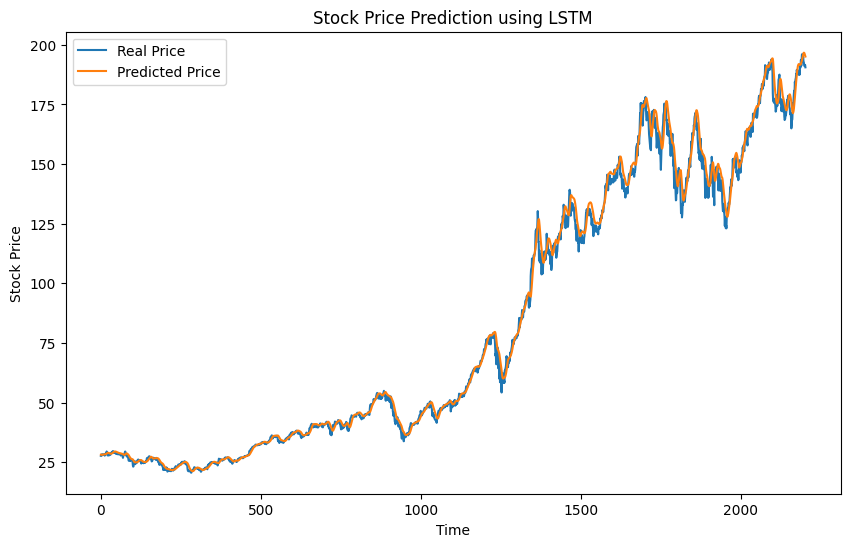

In [9]:
plt.figure(figsize=(10,6))

plt.plot(real_prices, label="Real Price")
plt.plot(predicted_prices, label="Predicted Price")

plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()
plt.show()